In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
#  Imports
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
#  Configurations
img_size = (224, 224)
batch_size = 8
input_shape = img_size + (3,)
train_dir = r'D:\FYP\dataset_split\train'
val_dir = r'D:\FYP\dataset_split\val'
test_dir = r'D:\FYP\dataset_split\test'


In [4]:
# ==============================
# Data Generators
# ==============================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and Test: only rescaling
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

# ==============================
# Train Generator
# ==============================

train_ds = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

# ==============================
# Validation Generator
# ==============================

val_ds = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ==============================
# Test Generator
# ==============================

test_ds = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ==============================
# Display Dataset Information
# ==============================

print("\n========== DATASET INFORMATION ==========")

print("Train images      :", train_ds.samples)
print("Validation images :", val_ds.samples)
print("Test images       :", test_ds.samples)

print("\nClass indices:")
print(train_ds.class_indices)

num_classes = train_ds.num_classes

print("\nNumber of classes :", num_classes)

Found 10500 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.

========== DATASET INFORMATION ==========
Train images      : 10500
Validation images : 3000
Test images       : 1500

Class indices:
{'aca': 0, 'normal': 1, 'scc': 2}

Number of classes : 3


In [5]:
#  Load Pretrained Model (MobileNet)
base_model = MobileNet(include_top=False, weights='imagenet', input_shape=input_shape)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 32s 2us/step


In [6]:
#  Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
#model.summary()

In [7]:
#  Training
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stop, reduce_lr]
)

c:\Users\Shahzaib Rashid\miniconda3\envs\tf_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 428s 324ms/step - accuracy: 0.8415 - loss: 0.3741 - val_accuracy: 0.9570 - val_loss: 0.1195 - learning_rate: 1.0000e-04
Epoch 2/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 250s 191ms/step - accuracy: 0.9497 - loss: 0.1224 - val_accuracy: 0.9600 - val_loss: 0.1049 - learning_rate: 1.0000e-04
Epoch 3/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 249s 190ms/step - accuracy: 0.9576 - loss: 0.1097 - val_accuracy: 0.9607 - val_loss: 0.0906 - learning_rate: 1.0000e-04
Epoch 4/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 247s 188ms/step - accuracy: 0.9624 - loss: 0.0965 - val_accuracy: 0.9683 - val_loss: 0.0726 - learning_rate: 1.0000e-04
Epoch 5/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 248s 189ms/step - accuracy: 0.9726 - loss: 0.0792 - val_accuracy: 0.9660 - val_loss: 0.0783 - learning_rate: 1.0000e-04
Epoch 6/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 248s 189ms/step - accuracy: 0.9708 - loss: 0.0781 - val_accuracy: 0.9780 - val_loss: 0.0558 - learning_rate: 1.0000e-04
Epoch 7/20
1313/1313 ━━━━━━━

In [8]:
#  Evaluation
evaluation = model.evaluate(test_ds)
print("Evaluation results:", evaluation)

188/188 ━━━━━━━━━━━━━━━━━━━━ 28s 147ms/step - accuracy: 0.9743 - loss: 0.0596
Evaluation results: [0.03550644963979721, 0.9860000014305115]


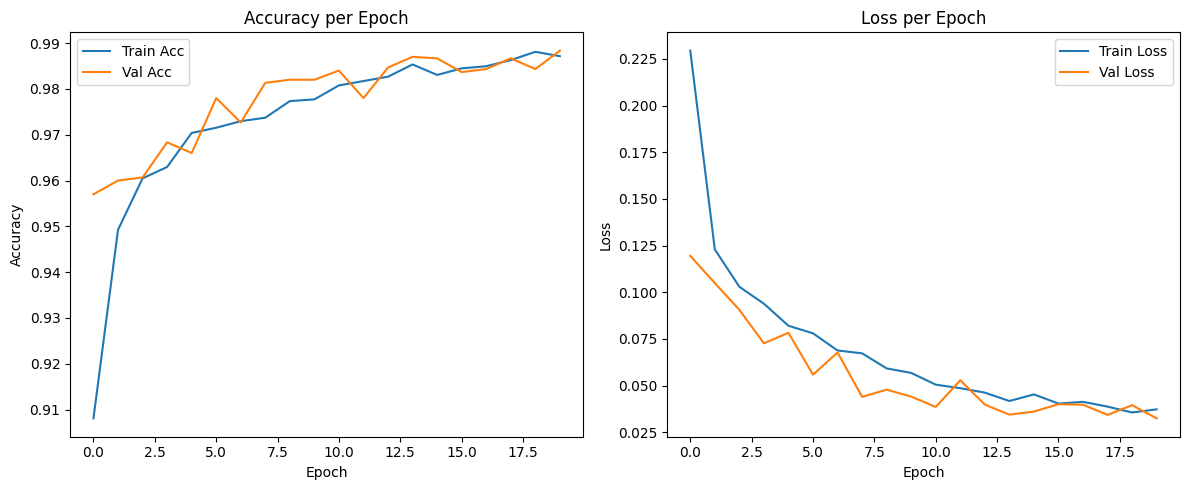

In [9]:
# Plot Accuracy & Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step


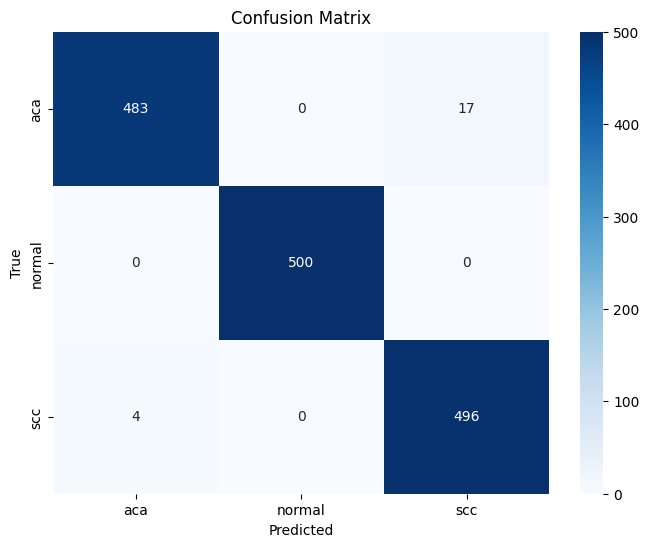

In [10]:
#  Evaluation: Confusion Matrix & All Metrics
test_ds.reset()
pred_probs = model.predict(test_ds, steps=len(test_ds), verbose=1)
y_pred = np.argmax(pred_probs, axis=1)

# True labels
y_true = []
for i in range(len(test_ds)):
    _, labels = test_ds[i]
    y_true.extend(np.argmax(labels, axis=1))
y_true = np.array(y_true)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_names = list(test_ds.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [11]:
# Metrics: Accuracy, Precision, Recall, F1
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Accuracy:  0.9860
Precision: 0.9862
Recall:    0.9860
F1-Score:  0.9860


In [12]:
#  Detailed Report
print("Classification Report Of M:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report Of M:
              precision    recall  f1-score   support

         aca       0.99      0.97      0.98       500
      normal       1.00      1.00      1.00       500
         scc       0.97      0.99      0.98       500

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500



In [13]:
model.save('MobileNet.keras')